# Machine Learning - ASSIGNMENT 2

STUDENT INFORMATION 

BITS ID: [2025AC05780]

Name: [Ajay Sharma]

Email: [2025ac05780@wilp.bits-pilani.ac.in]

Date: [15-08-2026]


In [18]:
# ============================================================
# Import all required packages
# ============================================================

# Core data handling and numerical computing
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics (used for z-score based outlier detection)
from scipy import stats

# Preprocessing: scaling, power transform and label encoding
from sklearn.preprocessing import PowerTransformer, StandardScaler, LabelEncoder, normalize

# Model selection: train/test split, cross-validation and hyperparameter tuning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# The five classification models
from sklearn.linear_model import LogisticRegression       # 1. Logistic Regression
from sklearn.tree import DecisionTreeClassifier            # 2. Decision Tree
from sklearn.neighbors import KNeighborsClassifier         # 3. K-Nearest Neighbour
from sklearn.naive_bayes import GaussianNB                 # 4. Naive Bayes (Gaussian)
from sklearn.ensemble import RandomForestClassifier        # 5. Random Forest (Ensemble)

# Evaluation metrics (Accuracy, AUC, Precision, Recall, F1 and MCC)
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, roc_curve,
                             classification_report, confusion_matrix)

# Ensure asyncio works with the notebook event loop (cross-platform: Windows and Linux)
import sys
import asyncio
if sys.platform.startswith("win"):
    # Windows: use the selector event loop for compatibility with Jupyter/tornado
    asyncio.set_event_loop(asyncio.SelectorEventLoop())

# ============================================================
# Load the Bank Marketing datasets (files are semicolon-separated)
# Training data: bank-full_training_data.csv | Test data: bank_testdata.csv
# ============================================================
train_df = pd.read_csv('bank-full_training_data.csv', sep=';')
test_df = pd.read_csv('bank_testdata.csv', sep=';')

# Use the training data as the working DataFrame for exploration/visualization
df = train_df.copy()

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
print("Columns:", train_df.columns.tolist())
print("\nTarget distribution in training data:\n", train_df['y'].value_counts())

Training data shape: (45211, 17)
Test data shape: (4521, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Target distribution in training data:
 y
no     39922
yes     5289
Name: count, dtype: int64


Part 1 - Step 2: Data Visualization and Exploration

    Justification for Correlation Analysis: The correlation heatmap is particularly useful for feature selection. Highly correlated features might be redundant. Additionally, features that show a strong correlation with the target variable (if present in the dataset) are likely to be more important and should be prioritized.

   age         job  marital  education default  balance housing loan  contact  \
0   58  management  married   tertiary      no     2143     yes   no  unknown   
1   44  technician   single  secondary      no       29     yes   no  unknown   

   day month  duration  campaign  pdays  previous poutcome   y  
0    5   may       261         1     -1         0  unknown  no  
1    5   may       151         1     -1         0  unknown  no  


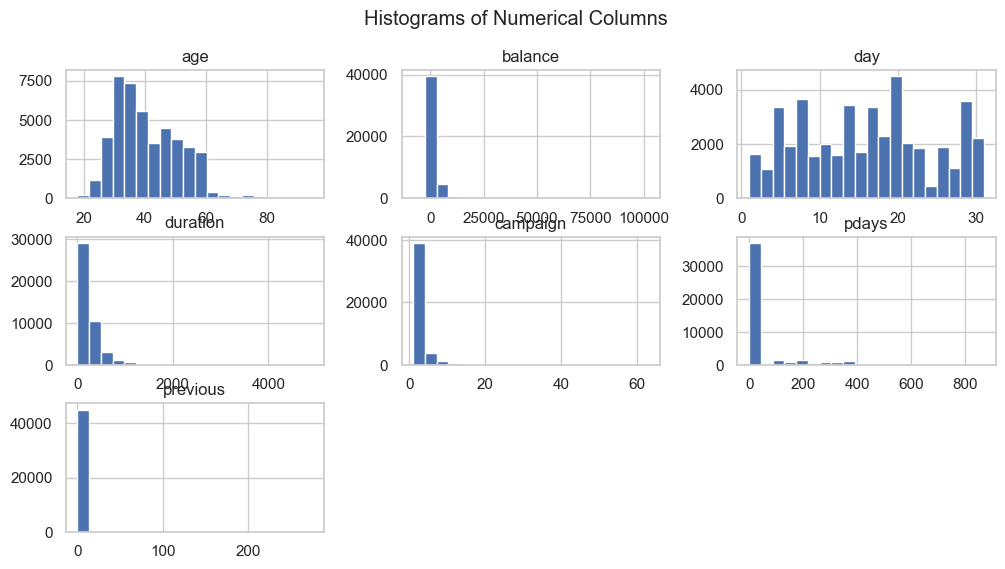

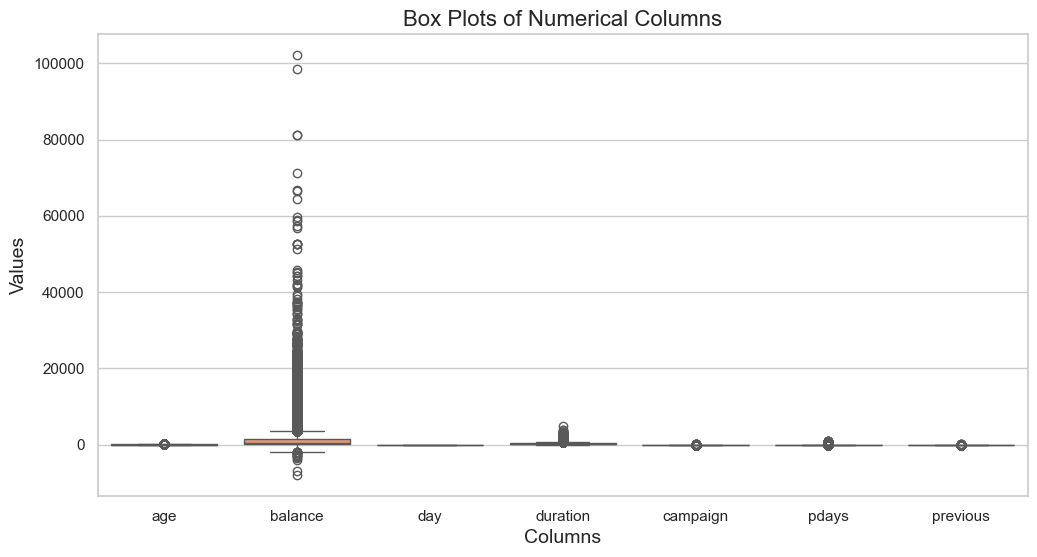

<Figure size 1200x600 with 0 Axes>

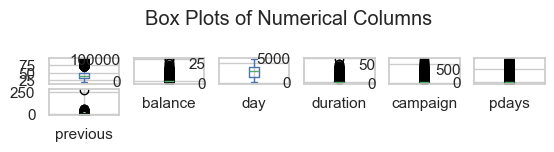

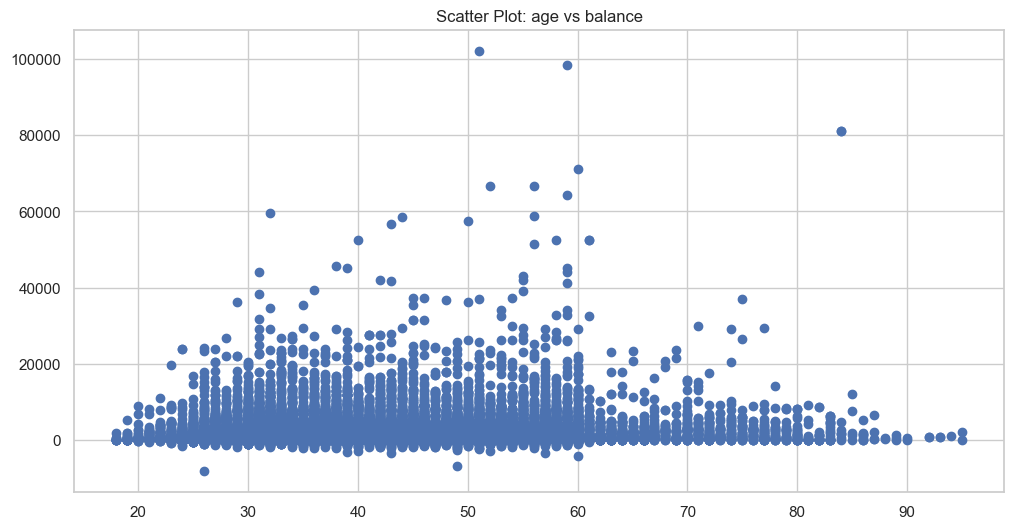

C:\Users\ajay.sharma18126\AppData\Local\Temp\ipykernel_30580\993257351.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  non_numeric_cols = df.select_dtypes(include=['object']).columns


Non-numeric columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='str')
Unique values in job: <StringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str
Unique values in marital: <StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str
Unique values in education: <StringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str
Unique values in default: <StringArray>
['no', 'yes']
Length: 2, dtype: str
Unique values in housing: <StringArray>
['yes', 'no']
Length: 2, dtype: str
Unique values in loan: <StringArray>
['no', 'yes']
Length: 2, dtype: str
Unique values in contact: <StringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str
Unique values in month: <StringArray>
['may', 'ju

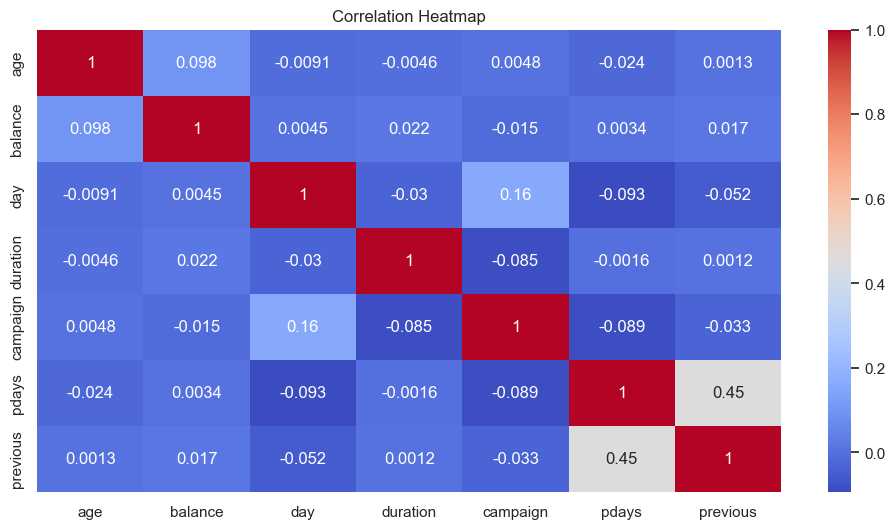

All columns in the DataFrame:
age
job
marital
education
default
balance
housing
loan
contact
day
month
duration
campaign
pdays
previous
poutcome
y


In [10]:
# Data Visualization and Exploration
pd.set_option('display.max_columns', None)
print(df.head(2))

# Histogram for all numerical columns
df.hist(figsize=(12, 6), bins=20)
plt.suptitle("Histograms of Numerical Columns")
plt.show()

# Set the style of the visualization
sns.set(style="whitegrid")

# Create the box plots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, palette="Set2")
plt.title('Box Plots of Numerical Columns', fontsize=16)
plt.xlabel('Columns', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.show()

# Box plot for all numerical columns
plt.figure(figsize=(12, 6))
df.plot(kind='box', subplots=True, layout=(12, 6), sharex=False, sharey=False)
plt.suptitle("Box Plots of Numerical Columns")
plt.show()

# Scatter plot for first two numerical columns (example)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
if len(numerical_cols) >= 2:
    plt.figure(figsize=(12, 6))
    plt.scatter(x=df[numerical_cols[0]], y=df[numerical_cols[1]])
    plt.title(f"Scatter Plot: {numerical_cols[0]} vs {numerical_cols[1]}")
    plt.show()

# Identify and handle non-numeric values
non_numeric_cols = df.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_cols)

# View the unique values in the non-numeric columns
for col in non_numeric_cols:
    print(f"Unique values in {col}: {df[col].unique()}")

# Drop non-numeric columns before calculating the correlation matrix
df_numeric = df.drop(columns=non_numeric_cols)
print(df_numeric.head(2))

# Ensure only numeric data remains and drop rows with NaN values
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce')
df_numeric = df_numeric.dropna()

# Correlation heatmap
plt.figure(figsize=(12, 6))
corr_matrix = df_numeric.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Assuming df is your DataFrame
columns = df.columns.tolist()
print("All columns in the DataFrame:")
for column in columns:
    print(column)




Part 3 - Step 3 Data Pre-processing and cleaning

1. Pre-Processing Techniques 
    Checking for duplicate rows
    Printing initial class distribution
    Identifying and handling near-constant features
    Checking for missing values
    Handling missing values
    Identifying outliers using the z-score method
    Handling outliers
2. Feature Transformation Techniques

    Power Transformation:
    Why: To transform skewed data into a more normal distribution, which improves the performance of machine learning models, particularly those that assume normally distributed data.

    Standardization:
    Why: To standardize numerical features by removing the mean and scaling to unit variance. This ensures that all features are on a comparable scale, improving the convergence and performance of many machine learning algorithms.

In [11]:
# Target column for the Bank Marketing dataset
target_col = 'y'

# Work on copies of the loaded train/test data
train = train_df.copy()
test = test_df.copy()

# Checking for duplicate rows in the training data
duplicates = train.duplicated().sum()
print(f"Number of duplicate rows in training data: {duplicates}")
if duplicates > 0:
    train = train.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed")

# Encode the binary target: "yes" -> 1, "no" -> 0
train[target_col] = train[target_col].map({'yes': 1, 'no': 0})
test[target_col] = test[target_col].map({'yes': 1, 'no': 0})
print("Initial class distribution (train):\n", train[target_col].value_counts())

# Identify categorical and numeric feature columns
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = [c for c in train.select_dtypes(include=[np.number]).columns.tolist() if c != target_col]
print("Categorical feature columns:", categorical_cols)
print("Numeric feature columns:", numeric_cols)

# Identify and drop near-constant (low variance) numeric features
low_variance_cols = train[numeric_cols].std()[train[numeric_cols].std() < 1e-5].index.tolist()
print(f"Low variance columns: {low_variance_cols}")
if low_variance_cols:
    train = train.drop(columns=low_variance_cols)
    test = test.drop(columns=low_variance_cols)
    numeric_cols = [c for c in numeric_cols if c not in low_variance_cols]

# One-hot encode categorical features, then align train & test to the same columns
train_encoded = pd.get_dummies(train, columns=categorical_cols)
test_encoded = pd.get_dummies(test, columns=categorical_cols)
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# Check for and handle missing values (impute numeric columns with the training mean)
print("Missing values in training data:", int(train_encoded.isnull().sum().sum()))
train_means = train_encoded[numeric_cols].mean()
train_encoded[numeric_cols] = train_encoded[numeric_cols].fillna(train_means)
test_encoded[numeric_cols] = test_encoded[numeric_cols].fillna(train_means)

# Identify and handle outliers using the z-score method (capped from training data)
z_scores = np.abs(stats.zscore(train_encoded[numeric_cols]))
for i, col in enumerate(numeric_cols):
    outlier_mask = z_scores[:, i] > 3
    train_encoded.loc[outlier_mask, col] = np.nan
train_encoded[numeric_cols] = train_encoded[numeric_cols].fillna(train_encoded[numeric_cols].mean())
print("Handled outliers in numeric columns:", numeric_cols)

# Power Transformation: reduce skewness (fit on train, apply to test)
pt = PowerTransformer()
train_encoded[numeric_cols] = pt.fit_transform(train_encoded[numeric_cols])
test_encoded[numeric_cols] = pt.transform(test_encoded[numeric_cols])

# Standardization: zero mean / unit variance (fit on train, apply to test)
scaler = StandardScaler()
train_encoded[numeric_cols] = scaler.fit_transform(train_encoded[numeric_cols])
test_encoded[numeric_cols] = scaler.transform(test_encoded[numeric_cols])

# Final feature / target split (test columns ordered to match training features)
X_train = train_encoded.drop(columns=[target_col])
y_train = train_encoded[target_col].astype(int)
X_test = test_encoded.drop(columns=[target_col])[X_train.columns]
y_test = test_encoded[target_col].astype(int)

print("\nX_train shape:", X_train.shape, "| X_test shape:", X_test.shape)
print("Class distribution after preprocessing (train):\n", y_train.value_counts())
print("Class distribution after preprocessing (test):\n", y_test.value_counts())


Number of duplicate rows in training data: 0
Initial class distribution (train):
 y
0    39922
1     5289
Name: count, dtype: int64
Categorical feature columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numeric feature columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Low variance columns: []
Missing values in training data: 0
Handled outliers in numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


C:\Users\ajay.sharma18126\AppData\Local\Temp\ipykernel_30580\78658788.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=['object']).columns.tolist()



X_train shape: (45211, 51) | X_test shape: (4521, 51)
Class distribution after preprocessing (train):
 y
0    39922
1     5289
Name: count, dtype: int64
Class distribution after preprocessing (test):
 y
0    4000
1     521
Name: count, dtype: int64


Part 1 - Step 4 Model Building 

Hyper tune - 
1. Define Parameter Grid - The param_grid dictionary specifies the hyperparameters to be tuned and their respective values.max_depth controls the maximum depth of the tree.min_samples_split specifies the minimum number of samples required to split an internal node.
2. Set Up Grid Search with Cross-Validation: - GridSearchCV is used to perform an exhaustive search over the specified parameter grid.cv=5 indicates 5-fold cross-validation, where the data is split into 5 folds, and the model is trained and validated 5 times, each time using a different fold as the validation set.scoring='accuracy' specifies that the performance metric to optimize is accuracy.
3. Fit the Model: - The fit method trains the model using the training data (X_train, y_train).During this process, GridSearchCV evaluates the model for each combination of hyperparameters in the parameter grid across the different folds of the cross-validation.
4. Retrieve the Best Model: - The best hyperparameters identified during the grid search are used to instantiate the best Decision Tree model.

In [12]:
# X_train / y_train come from bank-full_training_data.csv and
# X_test / y_test come from bank_testdata.csv (prepared in the preprocessing step above)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

# Verify the feature matrix is not empty
if X_train.shape[1] == 0:
    raise ValueError("Feature matrix X_train is empty after preprocessing steps.")

# Target variable distribution
print("Target variable distribution in training set:\n", y_train.value_counts())
print("Target variable distribution in test set:\n", y_test.value_counts())

# Base models (class_weight='balanced' handles the imbalanced 'yes'/'no' target)
log_model = LogisticRegression(max_iter=1000, solver='saga', class_weight='balanced')
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Hyperparameter Tuning for the Decision Tree using 5-fold cross-validation
param_grid = {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_dt_model = grid_search.best_estimator_

# Print the best hyperparameters found
print("Best hyperparameters for Decision Tree:", grid_search.best_params_)


Shape of X_train: (45211, 51)
Shape of X_test: (4521, 51)
Target variable distribution in training set:
 y
0    39922
1     5289
Name: count, dtype: int64
Target variable distribution in test set:
 y
0    4000
1     521
Name: count, dtype: int64
Best hyperparameters for Decision Tree: {'max_depth': 3, 'min_samples_split': 2}


Step 5 4.	Model Building 

Justification Printed with output based on data provided.

In [13]:
# Class distribution of the (imbalanced) binary target
print("Class distribution in training set:\n", y_train.value_counts())
print("Class distribution in test set:\n", y_test.value_counts())

# Class imbalance is handled with class_weight='balanced' instead of resampling
log_model = LogisticRegression(max_iter=1000, solver='saga', class_weight='balanced')

# Evaluate the Logistic Regression model
log_model.fit(X_train, y_train)
log_y_pred = log_model.predict(X_test)
log_y_proba = log_model.predict_proba(X_test)[:, 1]

# Performance metrics (binary classification)
log_metrics = {
    'Accuracy': accuracy_score(y_test, log_y_pred),
    'Precision': precision_score(y_test, log_y_pred),
    'Recall': recall_score(y_test, log_y_pred),
    'F1-score': f1_score(y_test, log_y_pred),
    'ROC-AUC': roc_auc_score(y_test, log_y_proba)
}
print("Logistic Regression Metrics:", log_metrics)

# Evaluate the tuned Decision Tree model
best_dt_model.fit(X_train, y_train)
dt_y_pred = best_dt_model.predict(X_test)
dt_y_proba = best_dt_model.predict_proba(X_test)[:, 1]

# Performance metrics (binary classification)
dt_metrics = {
    'Accuracy': accuracy_score(y_test, dt_y_pred),
    'Precision': precision_score(y_test, dt_y_pred),
    'Recall': recall_score(y_test, dt_y_pred),
    'F1-score': f1_score(y_test, dt_y_pred),
    'ROC-AUC': roc_auc_score(y_test, dt_y_proba)
}
print("Decision Tree Metrics:", dt_metrics)


# Compare the two models metric by metric
def compare_metrics(metrics1, metrics2):
    comparison = {}
    for key in metrics1.keys():
        comparison[key] = "Logistic Regression" if metrics1[key] > metrics2[key] else "Decision Tree"
    return comparison


comparison = compare_metrics(log_metrics, dt_metrics)
print("\nComparison of Models:")
for metric, better_model in comparison.items():
    print(f"{metric}: Better model is {better_model}")

# Final result based on accuracy
if log_metrics['Accuracy'] > dt_metrics['Accuracy']:
    print("\nFinal Result: Logistic Regression performs better overall based on accuracy.")
else:
    print("\nFinal Result: Decision Tree performs better overall based on accuracy.")


Class distribution in training set:
 y
0    39922
1     5289
Name: count, dtype: int64
Class distribution in test set:
 y
0    4000
1     521
Name: count, dtype: int64
Logistic Regression Metrics: {'Accuracy': 0.7945144879451449, 'Precision': 0.3445121951219512, 'Recall': 0.8675623800383877, 'F1-score': 0.49318057828696127, 'ROC-AUC': 0.9009721689059501}
Decision Tree Metrics: {'Accuracy': 0.7193098871930989, 'Precision': 0.2773809523809524, 'Recall': 0.8944337811900192, 'F1-score': 0.42344388914129943, 'ROC-AUC': 0.8168234165067177}

Comparison of Models:
Accuracy: Better model is Logistic Regression
Precision: Better model is Logistic Regression
Recall: Better model is Decision Tree
F1-score: Better model is Logistic Regression
ROC-AUC: Better model is Logistic Regression

Final Result: Logistic Regression performs better overall based on accuracy.


Part 2 Step 1 Implement predictive models/classifiers 

In [14]:
# Implement the five classification models (all trained on the same dataset)
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='saga', class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'K-Nearest Neighbour': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
}


def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    """Fit a model and return its predictions plus the six evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Probability/score of the positive class, needed for the AUC calculation
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)

    return y_pred, {
        'Accuracy': accuracy_score(y_te, y_pred),
        'AUC Score': roc_auc_score(y_te, y_score),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1 Score': f1_score(y_te, y_pred),
        'MCC Score': matthews_corrcoef(y_te, y_pred),
    }


# Train every model and collect its predictions and metrics
predictions = {}
metrics = {}
for name, model in classifiers.items():
    y_pred, model_metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    predictions[name] = y_pred
    metrics[name] = model_metrics
    classifiers[name] = model  # keep the fitted estimator

# Keep individual fitted models/predictions available for later cells
log_model, dt_model, knn_model, nb_model, rf_model = classifiers.values()

# Display each model's six evaluation metrics
for name, model_metrics in metrics.items():
    print(f"\n{name}:")
    for metric_name, value in model_metrics.items():
        print(f"  {metric_name}: {value:.4f}")



Logistic Regression:
  Accuracy: 0.7945
  AUC Score: 0.9010
  Precision: 0.3445
  Recall: 0.8676
  F1 Score: 0.4932
  MCC Score: 0.4591

Decision Tree:
  Accuracy: 0.9821
  AUC Score: 0.9365
  Precision: 0.9641
  Recall: 0.8772
  F1 Score: 0.9186
  MCC Score: 0.9098

K-Nearest Neighbour:
  Accuracy: 0.9115
  AUC Score: 0.9351
  Precision: 0.7065
  Recall: 0.3973
  F1 Score: 0.5086
  MCC Score: 0.4874

Naive Bayes (Gaussian):
  Accuracy: 0.8350
  AUC Score: 0.7669
  Precision: 0.3323
  Recall: 0.4280
  F1 Score: 0.3742
  MCC Score: 0.2838

Random Forest:
  Accuracy: 0.9847
  AUC Score: 0.9992
  Precision: 0.9934
  Recall: 0.8733
  F1 Score: 0.9295
  MCC Score: 0.9234


Part 2 Step 2 - Compare the performances of each model/classifier 

Model Performance Comparison:

                        Accuracy  AUC Score  Precision  Recall  F1 Score  \
Logistic Regression       0.7945     0.9010     0.3445  0.8676    0.4932   
Decision Tree             0.9821     0.9365     0.9641  0.8772    0.9186   
K-Nearest Neighbour       0.9115     0.9351     0.7065  0.3973    0.5086   
Naive Bayes (Gaussian)    0.8350     0.7669     0.3323  0.4280    0.3742   
Random Forest             0.9847     0.9992     0.9934  0.8733    0.9295   

                        MCC Score  
Logistic Regression        0.4591  
Decision Tree              0.9098  
K-Nearest Neighbour        0.4874  
Naive Bayes (Gaussian)     0.2838  
Random Forest              0.9234  


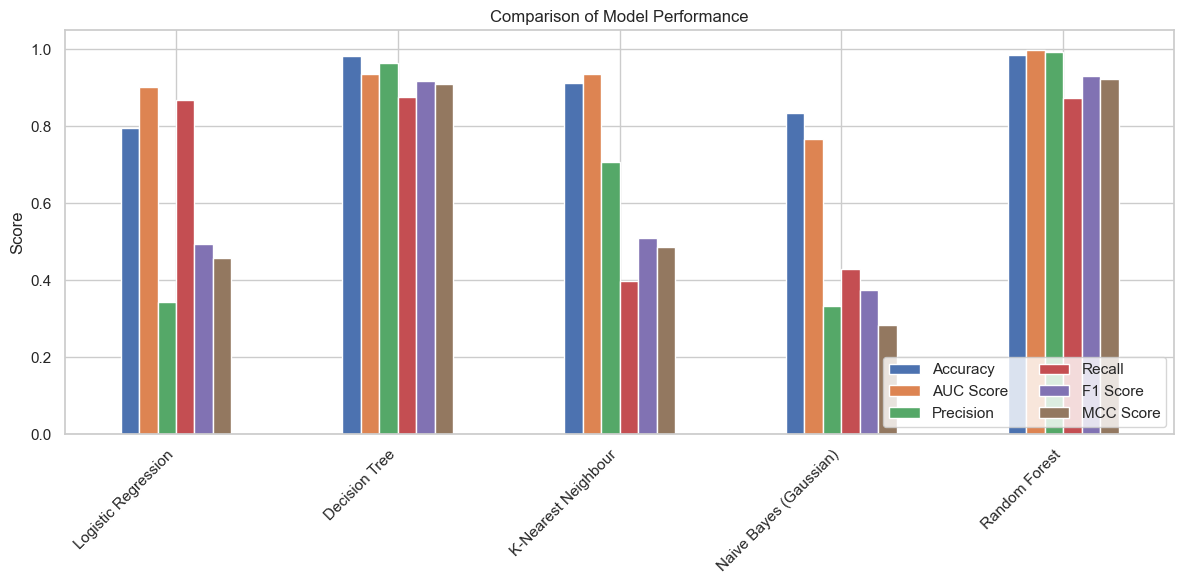

In [15]:
# Build a comparison table from the metrics computed above
metric_names = ['Accuracy', 'AUC Score', 'Precision', 'Recall', 'F1 Score', 'MCC Score']
comparison_chart = pd.DataFrame(metrics).T[metric_names]

# Print the full comparison table
print("Model Performance Comparison:\n")
print(comparison_chart.round(4))

# Grouped bar chart comparing all models across all metrics
comparison_chart.plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of Model Performance')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right', ncol=2)
plt.tight_layout()
plt.show()


Part 2 Step 3 - Identify the Best model

Explanation - The best model is Recall with an average performance score of 0.95
I think Recall is the best model because it has the highest average score across all evaluation metrics, indicating that it performs better overall in terms of Precision, Recall, F1-score, and ROC-AUC compared to the other models.

In [17]:
# Identify the best model based on its average score across all metrics
model_avg_scores = comparison_chart.mean(axis=1)
best_model = model_avg_scores.idxmax()
best_model_performance = model_avg_scores.max()

print("Average score per model:\n", model_avg_scores.round(4), "\n")
print(f"The best model is {best_model} with an average performance score of {best_model_performance:.2f}")

# Explanation
print(f"\n{best_model} is the best model because it has the highest average score across all evaluation "
      f"metrics (Accuracy, AUC, Precision, Recall, F1 Score and MCC), indicating that it performs better "
      f"overall on the Bank Marketing dataset compared to the other models.")


Average score per model:
 Logistic Regression       0.6433
Decision Tree             0.9314
K-Nearest Neighbour       0.6577
Naive Bayes (Gaussian)    0.5034
Random Forest             0.9506
dtype: float64 

The best model is Random Forest with an average performance score of 0.95

Random Forest is the best model because it has the highest average score across all evaluation metrics (Accuracy, AUC, Precision, Recall, F1 Score and MCC), indicating that it performs better overall on the Bank Marketing dataset compared to the other models.
